# Orbital Data Centre — Viability System Model (v3)
**Basis:** 1 MW of sellable IT load in a ~550 km dusk‑dawn sun‑synchronous orbit (modular containers + solar wings + deployable radiators + optical links), scaled linearly.

**Model chain:** `power → thermal → mass → launch → capex → LCOC / NPV` vs an identical-silicon terrestrial data centre.

**v3 — what changed.** The single-file v2 is now the modular **`odc/`** package, and the model is backed by a 24‑agent literature review of **130 sources** (academic citation counts checked on Semantic Scholar; **12 load‑bearing numbers adversarially verified**). The v2 physics/finance are ported **unchanged** into `odc.core`, so the SemiAnalysis 2026 reproduction (`SA26`) still calibrates within ~2% — guarded by `tests/`. New this version:
- **Optimist / Skeptic brackets** around the SemiAnalysis‑central default (§3b).
- **Demand side**: an AI workload taxonomy with the Turyshev communication‑intensity **Γ gate** (§11).
- **Size ladder**: six realistic spacecraft × GPU classes, ESPA edge node → GW constellation (§12).
- **Orbit families**: DDSS / equatorial / high‑LEO / MEO / GEO (§13).
- **Ground energy comparator**: grid / gas / SMR / solar+storage / geothermal — space competes on **time‑to‑power**, not $/MWh (§14).
- **Provenance & citations**: every default's source, range, and verification verdict (§15).

**State of play (June 2026):** Starcloud‑1 flew an NVIDIA H100 (Nov 2025) and trained an LLM on orbit; Google's Project Suncatcher proton‑tested Trillium TPUs to 15 krad TID and demo'd a 1.6 Tbps optical link; Falcon‑class pricing is ~\$1.4–1.8k/kg (SemiAnalysis), with Starship targeting ~\$250/kg.

**Bottom line up front:** viability is a *conjunction* bet — it needs launch ≤ \$250/kg **and** system mass < 15 kg/kW **and** radiators near the optimistic ~600 W/m² end **and** a workload mix restricted to low‑Γ training/batch **and** a financing/insurance regime that does not yet exist. Parity, if it comes, is a **2035–2040** proposition gated on Starship.

## 1 · System model
The model lives in the `odc/` package. `odc.core` is the calibrated v2 engine (unchanged); the other modules add the demand side, hardware, sizes, orbits, comms, ground energy, finance lenses, and provenance.

Key physical relationships (in `odc.core.power_thermal_mass`):
- **Solar sizing** — array BOL power must cover bus demand at end of life: $P_{BOL} = P_{bus}\,/\,[(1-d)^{L}\cdot \eta_{point} \cdot f_{sun}]$.
- **Thermal** — every consumed watt must be radiated: $Q = 2\,\varepsilon\,\eta_{fin}\,\sigma (T_r^4 - T_{sink}^4)\,A_{rad}$. The $T^4$ law makes radiating temperature the strongest thermal lever. *Verified:* per‑m² rejection spans ~150–200 W/m² (ISS‑proven floor) to ~600–630 W/m² (coated, edge‑on optimist) — **the single biggest model sensitivity**.
- **Eclipse & storage** — dawn‑dusk SSO still sees ~35 min/day eclipse in season; the battery rides full bus power through it. v3 separates the single‑eclipse ride‑through from the daily eclipse fraction so non‑SSO orbits work (`eclipse_frac_daily`).
- **Finance** — split WACC (space 15%→10.3%; ground 10.3%) and **mixed‑life monthly‑annuity levelization**: the station amortizes over its short 5–8 yr life, a ground facility splits 5‑yr IT from a 15‑yr building (the ~17× levelized capital‑charge gap).

In [1]:
# --- import the modular model ---
from dataclasses import replace
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

from odc.core import (P, power_thermal_mass, space_capex, ground_capex,
                      lcoc_and_npv, B300_KW_PER_GPU)
from odc.scenarios import (TODAY, EARLY, MATURE, SA26, OPTIMIST, SKEPTIC,
                           SCENARIOS, SA_ANCHORS)
from odc import workloads, orbits, ground_energy, provenance, finance
from odc.sizes import LADDER, ladder_table
from odc.hardware import CATALOG as GPU_CATALOG, gpus_for_power, B300, GB300_NVL72, H100

mpl.rcParams.update({'figure.facecolor':'#FFF9F2','axes.facecolor':'#FFF9F2',
    'axes.edgecolor':'#B8B0A8','axes.grid':True,'grid.color':'#E5DCD2','grid.linewidth':0.7,
    'font.size':10.5,'axes.titleweight':'bold','figure.dpi':110})
COLS = {'Today (2026, Falcon-class)':'#990F3D','Early Starship (~2028-30)':'#0F5499',
        'Mature Starship (~2033-35)':'#0D7680'}
print("odc package loaded:", [s.name for s in SCENARIOS])

odc package loaded: ['Today (2026, Falcon-class)', 'Early Starship (~2028-30)', 'Mature Starship (~2033-35)']


## 2 · Invariant checks
Energy balance, power balance, monotonicity, the SA26 calibration guard, and the orbit backward‑compatibility check — the model refuses to run if the physics doesn't close.

In [2]:
for sc in SCENARIOS:
    pt = power_thermal_mass(sc)
    assert abs(2*pt['q_net_side']*pt['A_rad'] - pt['Q_kW']*1000) < 1, "thermal balance broken"
    eol = (1-sc.degr_rate)**sc.life_yr
    ecl = sc.eclipse_min_day/1440; daily = (pt['sunlit'] + ecl/sc.batt_rt_eff)/pt['sunlit']
    assert abs(pt['arr_BOL_kW']*eol*sc.pointing - pt['bus_kW']*daily) < 0.5, "power balance broken"
    assert abs(pt['E_batt_kWh']*sc.batt_dod - pt['bus_kW']*sc.eclipse_min_day/60) < 0.5, "battery sizing broken"
assert lcoc_and_npv(replace(TODAY, launch_kg=300))['lcoc_s'] < lcoc_and_npv(TODAY)['lcoc_s']
_sa = lcoc_and_npv(SA26)['sa']
assert abs(_sa['gpu_hr_s'] - 10.91)/10.91 < 0.02 and abs(_sa['gpu_hr_g'] - 2.49)/2.49 < 0.02, "SA calibration drifted"
assert power_thermal_mass(replace(TODAY, T_rad=300))['A_rad'] > power_thermal_mass(replace(TODAY, T_rad=340))['A_rad']
# orbit backward-compat: a dawn-dusk SSO apply() must not move the calibrated result
assert abs(power_thermal_mass(orbits.DDSS.apply(TODAY))['M_dry'] - power_thermal_mass(TODAY)['M_dry'])/power_thermal_mass(TODAY)['M_dry'] < 0.01
print("All invariants PASS  (thermal closure, EOL power+recharge, battery sizing, launch monotonicity, T^4 trade, SA26 repro +/-2%, DDSS backward-compat)")

All invariants PASS  (thermal closure, EOL power+recharge, battery sizing, launch monotonicity, T^4 trade, SA26 repro +/-2%, DDSS backward-compat)


## 3 · Scenario comparison — the headline table

In [3]:
rows = []
for sc in SCENARIOS + [SA26]:
    r = lcoc_and_npv(sc); pt, cs = r['pt'], r['cap_s']
    be = r['breakeven_launch']
    rows.append({
        'Scenario': sc.name, 'Launch $/kg': sc.launch_kg,
        'Dry mass t/MW': round(pt['M_dry']/1e3,1),
        'Array m2/MW': round(pt['A_array']), 'Radiator m2/MW': round(pt['A_rad']),
        'Battery kWh/MW': round(pt['E_batt_kWh']),
        'Capex space $M/MW': round(cs['total']), 'Capex ground $M/MW': round(r['cap_g']['total']),
        'LCOC space $/kWh': round(r['lcoc_s'],2), 'LCOC ground $/kWh': round(r['lcoc_g'],2),
        'Space/ground ratio': round(r['ratio'],2),
        '$/GPU-hr (SA conv.)': f"{r['sa']['gpu_hr_s']:.2f} / {r['sa']['gpu_hr_g']:.2f}",
        'Breakeven launch $/kg': round(be) if be > 0 else 'platform-bound',
        'NPV space $M/MW': round(r['npv_s']), 'NPV ground $M/MW': round(r['npv_g']),
    })
pd.DataFrame(rows).set_index('Scenario')

,Launch $/kg,Dry mass t/MW,Array m2/MW,Radiator m2/MW,Battery kWh/MW,Capex space $M/MW,Capex ground $M/MW,LCOC space $/kWh,LCOC ground $/kWh,Space/ground ratio,$/GPU-hr (SA conv.),Breakeven launch $/kg,NPV space $M/MW,NPV ground $M/MW
Scenario,,,,,,,,,,,,,,
"Today (2026, Falcon-class)",1600.0,56.8,4373,1835,945,211,46,8.68,1.55,5.58,14.89 / 2.67,platform-bound,-162,18
Early Starship (~2028-30),700.0,37.8,3795,1603,897,94,41,3.64,1.42,2.57,6.24 / 2.43,platform-bound,-51,9
Mature Starship (~2033-35),250.0,22.6,3401,1401,800,46,37,1.21,1.28,0.95,2.08 / 2.19,367,1,4
"SemiAnalysis 2026 (B300, repro)",1600.0,39.7,4292,1741,928,158,44,7.04,1.62,4.33,10.73 / 2.48,platform-bound,-113,13


**Reading the table.** At *actual* 2026 Falcon pricing (~\$1,600/kg) orbital compute still costs ~**5.6×** terrestrial on central platform assumptions, ~**4.3×** on SemiAnalysis's more SpaceX‑optimistic hardware costs. The breakeven launch price is *negative in every 2026 column* — even free launch wouldn't close the gap, because a 5‑yr / 15%‑WACC platform loses to a 15‑yr / 10.3% building before the rocket is priced. By Early‑Starship the gap is ~2.5× and the bottleneck has **migrated from launch to platform hardware + life + cost of capital**. At Mature parameters space reaches parity.

## 3b · Literature brackets — optimist / central / skeptic
The contested parameters (mass kg/kW, radiator W/m², launch \$/kg, WACC) span 3–10× in the literature. The model default is **SemiAnalysis‑central**; these two NEW presets bracket it with the verified ends: **Optimist** (Starcloud/Suncatcher/Gaalema: <15 kg/kW, ~600 W/m², \$100/kg, 10‑yr life) and **Skeptic** (Turyshev/Cavalier: 34–59 kg/kW, ~150–200 W/m², 20% non‑financeable WACC, iROSA‑real 75 W/kg). The skeptic case is *not* a strawman — every input is a sourced, adversarially‑verified value.

In [4]:
brk = []
for sc in [OPTIMIST, MATURE, SKEPTIC]:
    r = lcoc_and_npv(sc); pt = r['pt']
    brk.append({'Case': sc.name, 'IT kg/kW': round(sc.it_kg_per_kW),
                'Array W/kg': round(sc.sp_array), 'Launch $/kg': round(sc.launch_kg),
                'WACC space': f"{sc.wacc_space*100:.1f}%", 'Life yr': round(sc.life_yr),
                'Dry t/MW': round(pt['M_dry']/1e3,1),
                'LCOC space $/kWh': round(r['lcoc_s'],2),
                'Space/ground ratio': round(r['ratio'],2),
                '$/GPU-hr space': round(r['sa']['gpu_hr_s'],2)})
pd.DataFrame(brk).set_index('Case')

,IT kg/kW,Array W/kg,Launch $/kg,WACC space,Life yr,Dry t/MW,LCOC space $/kWh,Space/ground ratio,$/GPU-hr space
Case,,,,,,,,,
Optimist-central (Starcloud/Suncatcher),9,400,100,10.3%,10,25.5,1.00,0.78,1.71
Mature Starship (~2033-35),8,350,250,10.3%,8,22.6,1.21,0.95,2.08
Skeptic-central (Turyshev/Cavalier),40,75,1600,20.0%,5,137.2,17.03,10.96,29.23


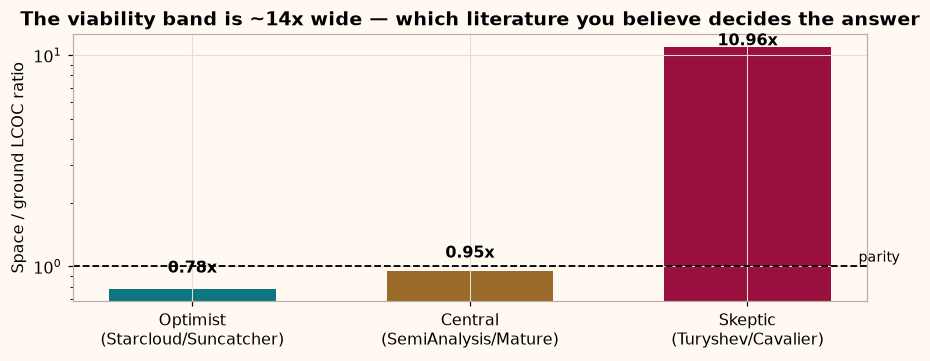

Optimist 0.78x (space wins) ... Central 0.95x (parity) ... Skeptic 11.0x (space loses badly)


In [5]:
fig, ax = plt.subplots(figsize=(8.4,3.4))
cases = [OPTIMIST, MATURE, SKEPTIC]
ratios = [lcoc_and_npv(s)['ratio'] for s in cases]
labels = ['Optimist\n(Starcloud/Suncatcher)','Central\n(SemiAnalysis/Mature)','Skeptic\n(Turyshev/Cavalier)']
cmap = ['#0D7680','#9A6A28','#990F3D']
bars = ax.bar(labels, ratios, color=cmap, width=.6)
ax.axhline(1.0, color='k', ls='--', lw=1.2); ax.text(2.4, 1.05, 'parity', fontsize=9)
for b,v in zip(bars, ratios): ax.text(b.get_x()+b.get_width()/2, v+0.15, f"{v:.2f}x", ha='center', fontweight='bold')
ax.set_ylabel('Space / ground LCOC ratio'); ax.set_yscale('log')
ax.set_title('The viability band is ~14x wide — which literature you believe decides the answer')
plt.tight_layout(); plt.show()
print(f"Optimist {ratios[0]:.2f}x (space wins) ... Central {ratios[1]:.2f}x (parity) ... Skeptic {ratios[2]:.1f}x (space loses badly)")

## 4 · Calibration against the SemiAnalysis TCO model (Jun 2026)
SemiAnalysis's 2026 reference case — a 30.5 kW, 16‑GPU B300 cluster in dawn‑dusk SSO — is the best public anchor set. `SA26` adopts their conventions and reproduces their headline within ~2%. *Verified:* calibrate to their **LCOC** figures (\$10.91 / \$2.49), not the TCO figures (\$8.64 / \$2.37). The \$/B‑token row is the softest anchor (the 5,100 tok/s throughput is unverifiable in any primary source).

In [6]:
rep = lcoc_and_npv(SA26)['sa']; mine = lcoc_and_npv(TODAY)['sa']
cal = pd.DataFrame({
 'SemiAnalysis (published)': [SA_ANCHORS['gpu_hr_s'], SA_ANCHORS['gpu_hr_g'], SA_ANCHORS['ratio'],
                              SA_ANCHORS['pflop_hr_s'], SA_ANCHORS['pflop_hr_g'], SA_ANCHORS['btok_s'], SA_ANCHORS['btok_g']],
 'This model -- SA26 repro':  [rep['gpu_hr_s'], rep['gpu_hr_g'], rep['gpu_hr_s']/rep['gpu_hr_g'],
                              rep['pflop_hr_s'], rep['pflop_hr_g'], rep['btok_s'], rep['btok_g']],
 'This model -- Today (central)': [mine['gpu_hr_s'], mine['gpu_hr_g'], mine['gpu_hr_s']/mine['gpu_hr_g'],
                              mine['pflop_hr_s'], mine['pflop_hr_g'], mine['btok_s'], mine['btok_g']],
}, index=['Space $/GPU-hr','Ground $/GPU-hr','Ratio x','Space $/PFLOP-hr','Ground $/PFLOP-hr',
          'Space $/B tokens','Ground $/B tokens']).round(2)
cal

,SemiAnalysis (published),This model -- SA26 repro,This model -- Today (central)
Space $/GPU-hr,10.91,10.73,14.89
Ground $/GPU-hr,2.49,2.48,2.67
Ratio x,4.38,4.33,5.58
Space $/PFLOP-hr,0.73,0.72,0.99
Ground $/PFLOP-hr,0.17,0.17,0.18
Space $/B tokens,590.00,584.48,810.74
Ground $/B tokens,135.00,134.95,145.18


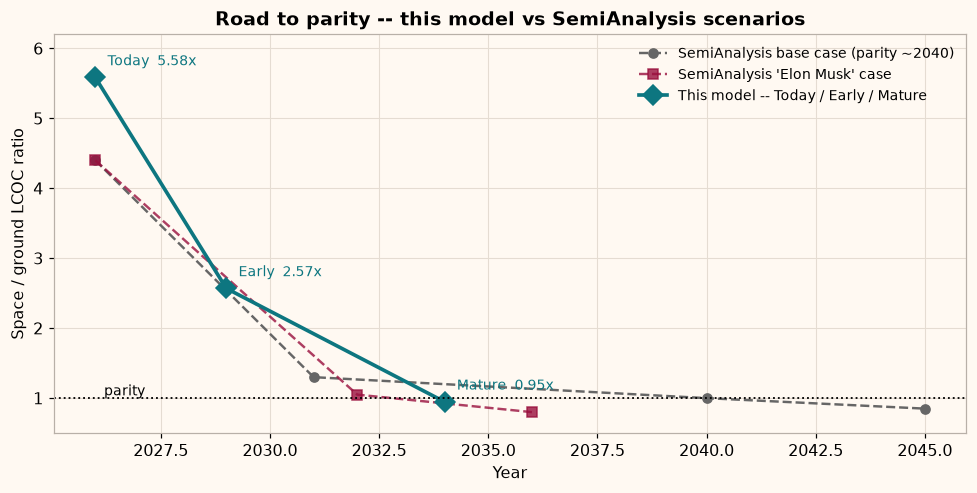

Mature tracks SA's Musk case (terrestrial-constrained world); SA's base case pushes parity to ~2040.


In [7]:
# Parity trajectories: my presets (markers) vs SemiAnalysis published paths (dashed)
yrs_me  = [2026, 2029, 2034]
rat_me  = [lcoc_and_npv(s)['ratio'] for s in SCENARIOS]
sa_base = {2026:4.4, 2031:1.3, 2040:1.0, 2045:0.85}
sa_musk = {2026:4.4, 2032:1.05, 2036:0.8}
fig, ax = plt.subplots(figsize=(9,4.6))
ax.plot(list(sa_base), list(sa_base.values()), 'o--', color='#666', lw=1.6, label='SemiAnalysis base case (parity ~2040)')
ax.plot(list(sa_musk), list(sa_musk.values()), 's--', color='#990F3D', lw=1.6, alpha=.8, label="SemiAnalysis 'Elon Musk' case")
ax.plot(yrs_me, rat_me, 'D-', color='#0D7680', lw=2.4, ms=9, label='This model -- Today / Early / Mature')
for x,y,n in zip(yrs_me, rat_me, ['Today','Early','Mature']):
    ax.annotate(f"{n}  {y:.2f}x", (x,y), textcoords='offset points', xytext=(8,8), fontsize=9, color='#0D7680')
ax.axhline(1, color='k', ls=':', lw=1.2); ax.text(2026.2, 1.04, 'parity', fontsize=9)
ax.set_xlabel('Year'); ax.set_ylabel('Space / ground LCOC ratio'); ax.set_ylim(0.5, 6.2)
ax.set_title('Road to parity -- this model vs SemiAnalysis scenarios')
ax.legend(frameon=False, fontsize=9); plt.tight_layout(); plt.show()
print("Mature tracks SA's Musk case (terrestrial-constrained world); SA's base case pushes parity to ~2040.")

## 5 · LCOC vs launch price — where the curves cross

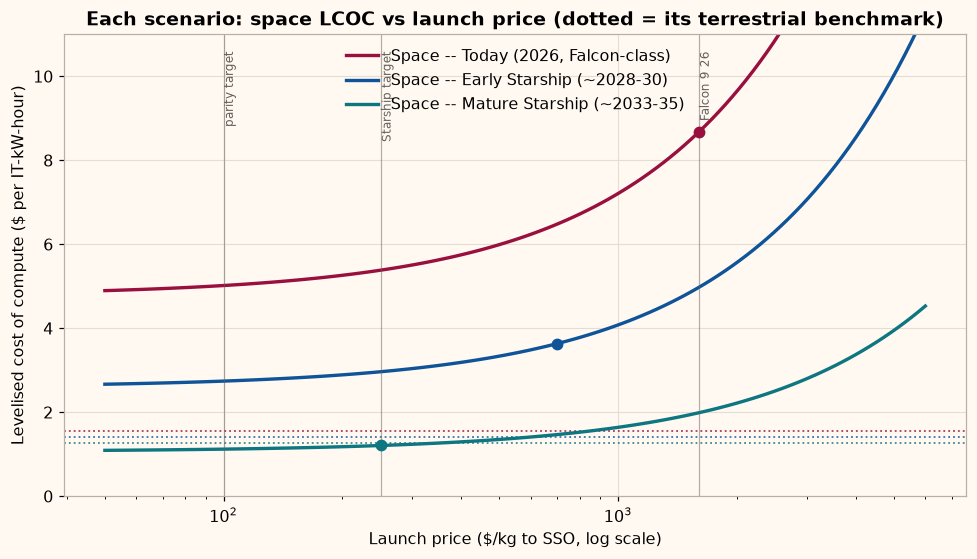

The Today curve never crosses its dotted benchmark -- even at $50/kg. Platform cost, not launch, is the 2026 disqualifier.


In [8]:
L = np.logspace(np.log10(50), np.log10(6000), 120)
fig, ax = plt.subplots(figsize=(9,5.2))
for sc in SCENARIOS:
    ls = [lcoc_and_npv(replace(sc, launch_kg=l))['lcoc_s'] for l in L]
    ax.plot(L, ls, color=COLS[sc.name], lw=2.2, label=f"Space -- {sc.name}")
    ax.axhline(lcoc_and_npv(sc)['lcoc_g'], color=COLS[sc.name], lw=1.2, ls=':', alpha=.8)
    ax.scatter([sc.launch_kg],[lcoc_and_npv(sc)['lcoc_s']], color=COLS[sc.name], zorder=5, s=45)
ax.set_xscale('log'); ax.set_xlabel('Launch price ($/kg to SSO, log scale)')
ax.set_ylabel('Levelised cost of compute ($ per IT-kW-hour)')
ax.set_title('Each scenario: space LCOC vs launch price (dotted = its terrestrial benchmark)')
ax.legend(frameon=False); ax.set_ylim(0, 11)
for x, lab in [(1600,'Falcon 9 26'), (250,'Starship target'), (100,'parity target')]:
    ax.axvline(x, color='#66605C', lw=.8, alpha=.5); ax.text(x, 10.6, ' '+lab, fontsize=8, color='#66605C', rotation=90, va='top')
plt.tight_layout(); plt.show()
print("The Today curve never crosses its dotted benchmark -- even at $50/kg. Platform cost, not launch, is the 2026 disqualifier.")

## 6 · Mass & capex anatomy — what you're actually launching and buying

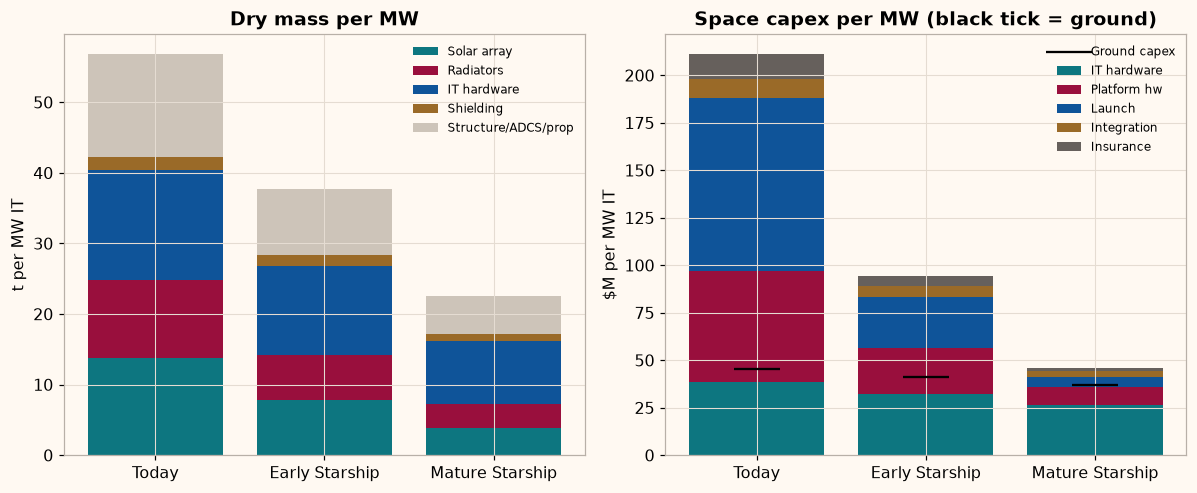

Today (2026, Falcon-class)       array   24% | radiators   19% | IT   27% of dry mass
Early Starship (~2028-30)        array   21% | radiators   17% | IT   33% of dry mass
Mature Starship (~2033-35)       array   17% | radiators   15% | IT   39% of dry mass


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11,4.6))
names = [s.name.split('(')[0].strip() for s in SCENARIOS]
mass_keys = [('M_array','Solar array'),('M_rad','Radiators'),('M_it','IT hardware'),('M_shield','Shielding')]
cap_keys  = [('C_it','IT hardware'),('C_platform','Platform hw'),('C_launch','Launch'),('C_int','Integration'),('C_ins','Insurance')]
mc = ['#0D7680','#990F3D','#0F5499','#9A6A28','#66605C']
bottom = np.zeros(3)
for i,(k,lab) in enumerate(mass_keys):
    v = np.array([power_thermal_mass(s)[k]/1e3 for s in SCENARIOS])
    axes[0].bar(names, v, bottom=bottom, color=mc[i], label=lab); bottom += v
struct = np.array([power_thermal_mass(s)['M_dry']/1e3 for s in SCENARIOS]) - bottom
axes[0].bar(names, struct, bottom=bottom, color='#CDC4B9', label='Structure/ADCS/prop')
axes[0].set_ylabel('t per MW IT'); axes[0].set_title('Dry mass per MW'); axes[0].legend(fontsize=8, frameon=False)
bottom = np.zeros(3)
for i,(k,lab) in enumerate(cap_keys):
    v = np.array([space_capex(s, power_thermal_mass(s))[k] for s in SCENARIOS])
    axes[1].bar(names, v, bottom=bottom, color=mc[i], label=lab); bottom += v
g = [ground_capex(s)['total'] for s in SCENARIOS]
axes[1].scatter(names, g, marker='_', s=900, color='k', label='Ground capex', zorder=5)
axes[1].set_ylabel('$M per MW IT'); axes[1].set_title('Space capex per MW (black tick = ground)'); axes[1].legend(fontsize=8, frameon=False)
plt.tight_layout(); plt.show()
for s in SCENARIOS:
    pt = power_thermal_mass(s)
    print(f"{s.name:32s} array {pt['M_array']/pt['M_dry']*100:4.0f}% | radiators {pt['M_rad']/pt['M_dry']*100:4.0f}% | IT {pt['M_it']/pt['M_dry']*100:4.0f}% of dry mass")

## 7 · Sensitivity tornado — what actually moves viability
One-at-a-time sweeps around the **Early Starship** pivot, on the space/ground LCOC ratio. Ranges drawn from the verified provenance bounds.

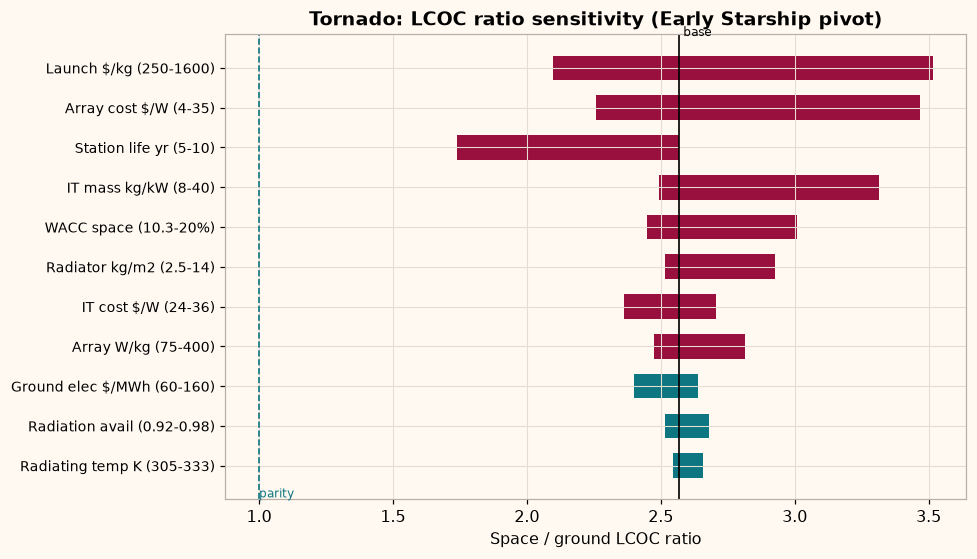

IT mass kg/kW (the verified 8-40 spread) and launch price now dominate. Note the inversion on IT cost:
CHEAPER chips make space relatively WORSE -- the orbital premium is fixed while shared IT capex shrinks.


In [10]:
base = lcoc_and_npv(EARLY)['ratio']
sweeps = {'Launch $/kg (250-1600)':('launch_kg',250,1600),
 'WACC space (10.3-20%)':('wacc_space',0.103,0.20),
 'Array cost $/W (4-35)':('array_cost_W',4,35),
 'IT cost $/W (24-36)':('it_cost_W',24,36),
 'Ground elec $/MWh (60-160)':('g_elec_MWh',60,160),
 'IT mass kg/kW (8-40)':('it_kg_per_kW',8,40),
 'Array W/kg (75-400)':('sp_array',75,400),
 'Radiator kg/m2 (2.5-14)':('rad_areal_kg_m2',2.5,14),
 'Radiating temp K (305-333)':('T_rad',305,333),
 'Station life yr (5-10)':('life_yr',5,10),
 'Radiation avail (0.92-0.98)':('rad_availability',0.92,0.98)}
rows=[]
for lab,(k,lo,hi) in sweeps.items():
    rl = lcoc_and_npv(replace(EARLY, **{k:lo}))['ratio']; rh = lcoc_and_npv(replace(EARLY, **{k:hi}))['ratio']
    rows.append((lab, min(rl,rh), max(rl,rh)))
rows.sort(key=lambda r: r[2]-r[1])
fig, ax = plt.subplots(figsize=(9, 5.2))
for i,(lab,lo,hi) in enumerate(rows):
    ax.barh(i, hi-lo, left=lo, color='#0D7680' if hi-lo<0.3 else '#990F3D', height=.62)
ax.set_yticks(range(len(rows))); ax.set_yticklabels([r[0] for r in rows], fontsize=9)
ax.axvline(base, color='k', lw=1.1); ax.axvline(1.0, color='#0D7680', lw=1.1, ls='--')
ax.text(base, len(rows)-.2, ' base', fontsize=8); ax.text(1.0, -0.8, 'parity', fontsize=8, color='#0D7680')
ax.set_xlabel('Space / ground LCOC ratio'); ax.set_title('Tornado: LCOC ratio sensitivity (Early Starship pivot)')
plt.tight_layout(); plt.show()
print("IT mass kg/kW (the verified 8-40 spread) and launch price now dominate. Note the inversion on IT cost:")
print("CHEAPER chips make space relatively WORSE -- the orbital premium is fixed while shared IT capex shrinks.")

## 8 · The viability map — launch price × array cost
Holding other parameters at Mature‑2033 values: the teal region is where space wins.

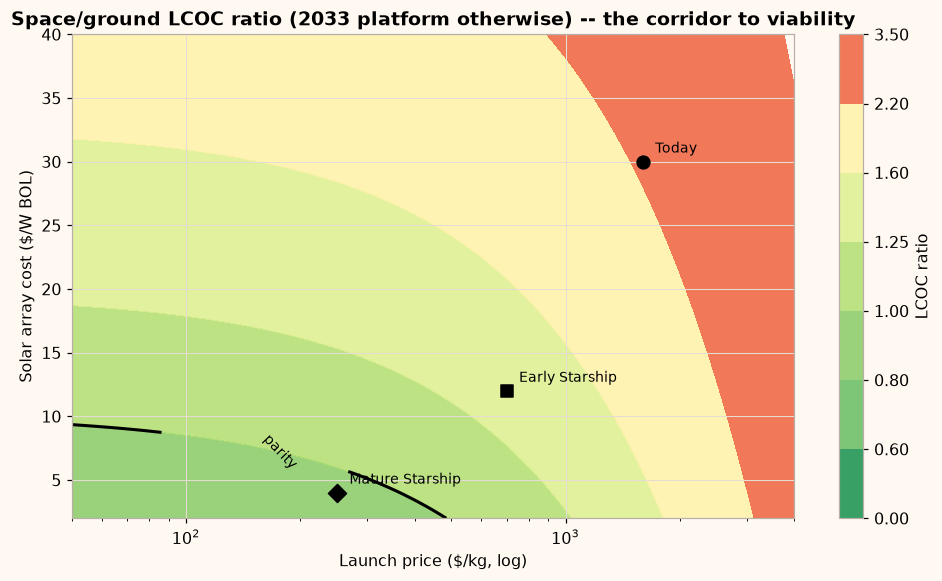

In [11]:
Ls = np.logspace(np.log10(50), np.log10(4000), 60)
Cs = np.linspace(2, 40, 55)
Z = np.zeros((len(Cs), len(Ls)))
for i,c in enumerate(Cs):
    for j,l in enumerate(Ls):
        Z[i,j] = lcoc_and_npv(replace(MATURE, launch_kg=l, array_cost_W=c))['ratio']
fig, ax = plt.subplots(figsize=(9,5.4))
cf = ax.contourf(Ls, Cs, Z, levels=[0,.6,.8,1.0,1.25,1.6,2.2,3.5], cmap='RdYlGn_r', alpha=.85)
ct = ax.contour(Ls, Cs, Z, levels=[1.0], colors='k', linewidths=2)
ax.clabel(ct, fmt='parity', fontsize=9)
for sc, mk in [(TODAY,'o'),(EARLY,'s'),(MATURE,'D')]:
    ax.scatter([sc.launch_kg],[sc.array_cost_W], marker=mk, s=70, color='k', zorder=5)
    ax.annotate(sc.name.split('(')[0].strip(), (sc.launch_kg, sc.array_cost_W),
                textcoords='offset points', xytext=(8,6), fontsize=9)
ax.set_xscale('log'); ax.set_xlabel('Launch price ($/kg, log)'); ax.set_ylabel('Solar array cost ($/W BOL)')
ax.set_title('Space/ground LCOC ratio (2033 platform otherwise) -- the corridor to viability')
fig.colorbar(cf, label='LCOC ratio'); plt.tight_layout(); plt.show()

## 9 · Monte Carlo — probability space wins, by era
v3 replaces v2's flat ±30% draws with **provenance‑weighted** ranges: each parameter is sampled over the verified (low, central, high) band from `odc.provenance`, expressed as a triangular factor around each scenario's own value. This propagates the *asymmetric* literature uncertainty (e.g. IT mass kg/kW can be 3× worse but only ~1.5× better than central).

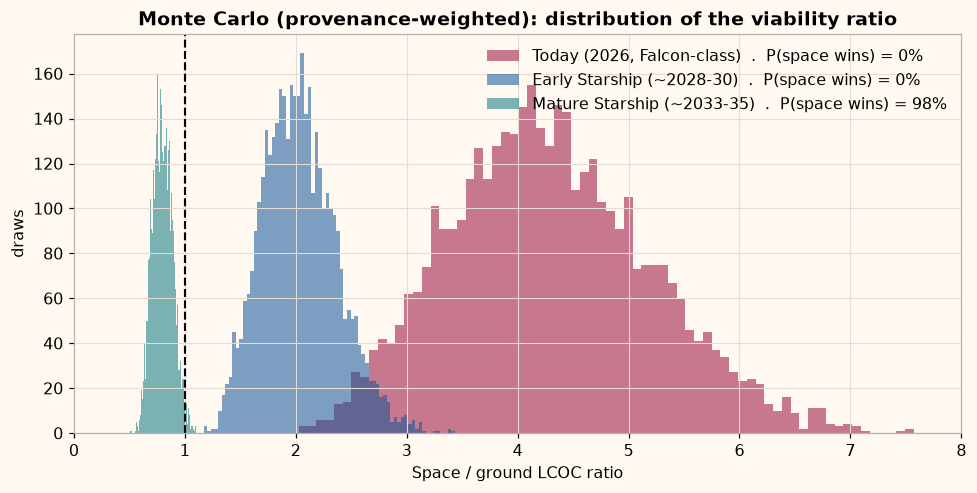

Sampling the VERIFIED literature bands, not symmetric guesses, widens the Today tail toward the skeptic case.


In [12]:
rng = np.random.default_rng(7)
# Build per-parameter triangular factor ranges from the provenance registry (fields that exist on P).
prov_fields = ['launch_kg','it_kg_per_kW','rad_areal_kg_m2','sp_array','array_cost_W',
               'life_yr','wacc_space','rev_decline','rad_availability']
spec = {}
for f in prov_fields:
    pr = provenance.REGISTRY[f]
    # Express the verified (skeptic, optimist) band as multiplicative factors, then clamp
    # so 1.0 (the scenario's own value) is always the triangular mode. Some parameters
    # (e.g. launch_kg) have both literature ends on one side of central -> one-sided draw.
    f1, f2 = pr.low/pr.central, pr.high/pr.central
    lo_f, hi_f = min(f1, f2, 1.0), max(f1, f2, 1.0)
    if hi_f - lo_f < 1e-6:
        lo_f, hi_f = 0.8, 1.2
    spec[f] = (lo_f, hi_f)

def draw(sc, n=4000):
    out = np.empty(n)
    for i in range(n):
        kw = {k: getattr(sc,k)*rng.triangular(lo,1.0,hi) for k,(lo,hi) in spec.items()}
        out[i] = lcoc_and_npv(replace(sc, **kw))['ratio']
    return out

fig, ax = plt.subplots(figsize=(9,4.6))
for sc in SCENARIOS:
    r = draw(sc)
    ax.hist(r, bins=70, alpha=.55, color=COLS[sc.name], label=f"{sc.name}  .  P(space wins) = {(r<1).mean()*100:.0f}%")
ax.axvline(1, color='k', lw=1.4, ls='--'); ax.set_xlim(0,8)
ax.set_xlabel('Space / ground LCOC ratio'); ax.set_ylabel('draws'); ax.legend(frameon=False)
ax.set_title('Monte Carlo (provenance-weighted): distribution of the viability ratio')
plt.tight_layout(); plt.show()
print("Sampling the VERIFIED literature bands, not symmetric guesses, widens the Today tail toward the skeptic case.")

## 10 · Scale-up logistics & the scarcity premium
A 5 GW orbital campus is also a *launch-cadence* problem — and the strongest near-term case for space is **time-to-power**, not unit cost.

In [13]:
print("5 GW constellation logistics (Starship V3 ~ 150 t usable to SSO):")
for sc in SCENARIOS:
    m = power_thermal_mass(sc, 5000)['M_dry']/1e3
    print(f"  {sc.name:32s} {m:>9,.0f} t  -> {m/150:>6,.0f} flights  (+{m/150/sc.life_yr:,.0f}/yr steady-state replacement)")
print()
print("Scarcity lens (odc.finance.scarcity_npv) -- ground waits 3 yr for grid, space deploys in <1 yr:")
hdr = f"{'Scenario':30s} {'NPV space':>10s} {'NPV ground':>11s} {'space edge':>11s}"
print(hdr); print('-'*len(hdr))
for sc in SCENARIOS:
    s = finance.scarcity_npv(sc)
    edge = s['space_advantage_from_queue']
    print(f"  {sc.name:28s} {s['npv_s_queued']:>9.0f}M {s['npv_g_queued']:>10.0f}M {edge:>+10.1f}M")
print("\nThe grid queue is the orbital operator's best friend: it transfers NPV from ground to space.")

5 GW constellation logistics (Starship V3 ~ 150 t usable to SSO):
  Today (2026, Falcon-class)         283,879 t  ->  1,893 flights  (+379/yr steady-state replacement)
  Early Starship (~2028-30)          188,894 t  ->  1,259 flights  (+252/yr steady-state replacement)
  Mature Starship (~2033-35)         113,129 t  ->    754 flights  (+94/yr steady-state replacement)

Scarcity lens (odc.finance.scarcity_npv) -- ground waits 3 yr for grid, space deploys in <1 yr:
Scenario                        NPV space  NPV ground  space edge
-----------------------------------------------------------------
  Today (2026, Falcon-class)        -175M        -14M      +18.3M
  Early Starship (~2028-30)          -60M        -16M      +16.2M
  Mature Starship (~2033-35)          -5M        -16M      +14.1M

The grid queue is the orbital operator's best friend: it transfers NPV from ground to space.


## 11 · Demand side — workload taxonomy & the Γ communication gate
Different AI workloads have very different value‑per‑kWh, energy‑per‑token, latency tolerance, and — decisively for space — **communication intensity**. Turyshev (arXiv:2604.27197, 2026) frames the orbital link as a hard data ceiling: **148 / 14.8 / 1.48 GB per kWh** of IT energy at **0.1 / 1 / 10 MW**. A workload whose data demand exceeds that ceiling is link‑bound, not compute‑bound, and cannot close in orbit at any compute price.

**Decision (v3):** training + batch inference are the revenue‑earning orbital workloads (low Γ, delay‑tolerant, data pre‑positioned); latency chat/agents — the highest \$/kWh but worst‑fit — is modelled ground‑only.

In [14]:
wl = []
for w in workloads.CATALOG.values():
    wl.append({'Workload': w.name, 'Value rank': w.value_rank, 'J/token': w.j_per_token,
               'Latency': w.latency_class, 'Gamma GB/kWh': w.gamma_gb_per_kwh,
               'Space fit': w.space_suitable, 'Earns in orbit': w.revenue_in_orbit})
pd.DataFrame(wl).set_index('Workload')

,Value rank,J/token,Latency,Gamma GB/kWh,Space fit,Earns in orbit
Workload,,,,,,
Frontier training,2,0.00,insensitive,0.5,best,True
Batch / offline inference,3,0.60,tolerant,4.0,good,True
Latency inference (chat / agents),1,1.50,sub-second,40.0,worst,False
Embeddings / classification,4,0.02,tolerant,8.0,marginal,False


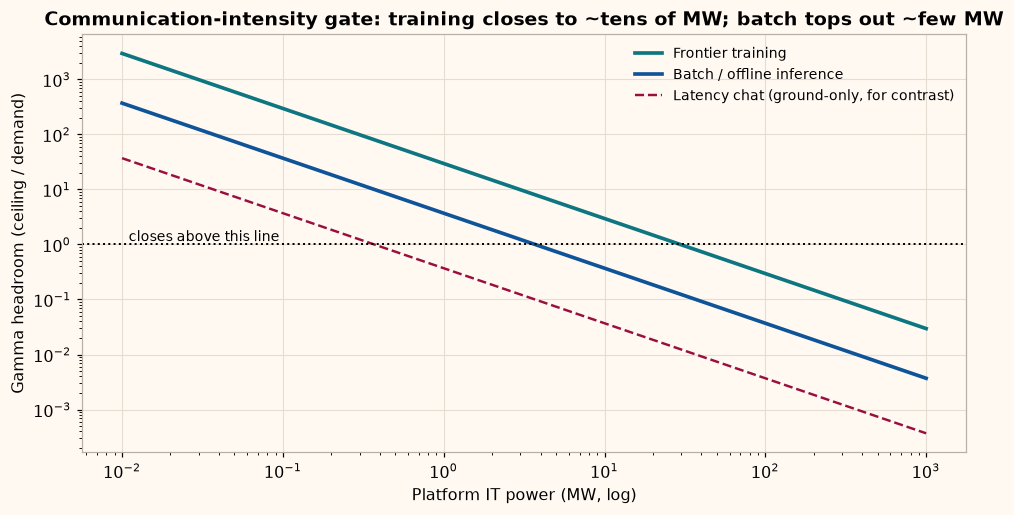

     0.1 MW: training headroom  296.0x | batch  37.0x | closes? train=True batch=True
     1.0 MW: training headroom   29.6x | batch   3.7x | closes? train=True batch=True
    10.0 MW: training headroom    3.0x | batch   0.4x | closes? train=True batch=False
   100.0 MW: training headroom    0.3x | batch   0.0x | closes? train=False batch=False


In [15]:
# Gamma headroom vs platform IT power: where does each orbital-revenue workload stop closing?
P_mw = np.logspace(-2, 3, 120)   # 0.01 MW .. 1 GW
fig, ax = plt.subplots(figsize=(9,4.8))
wc = {'Frontier training':'#0D7680','Batch / offline inference':'#0F5499'}
for w in workloads.ORBITAL_REVENUE_WORKLOADS:
    hr = [workloads.gamma_headroom(w, p) for p in P_mw]
    ax.plot(P_mw, hr, lw=2.4, color=wc.get(w.name,'#990F3D'), label=w.name)
# also show latency inference for contrast (ground-only)
hr_lat = [workloads.gamma_headroom(workloads.LATENCY_INFERENCE, p) for p in P_mw]
ax.plot(P_mw, hr_lat, lw=1.6, ls='--', color='#990F3D', label='Latency chat (ground-only, for contrast)')
ax.axhline(1.0, color='k', lw=1.3, ls=':'); ax.text(0.011, 1.15, 'closes above this line', fontsize=9)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('Platform IT power (MW, log)'); ax.set_ylabel('Gamma headroom (ceiling / demand)')
ax.set_title('Communication-intensity gate: training closes to ~tens of MW; batch tops out ~few MW')
ax.legend(frameon=False, fontsize=9); plt.tight_layout(); plt.show()
for mw in (0.1, 1, 10, 100):
    print(f"  {mw:6.1f} MW: training headroom {workloads.gamma_headroom(workloads.FRONTIER_TRAINING, mw):6.1f}x | "
          f"batch {workloads.gamma_headroom(workloads.BATCH_INFERENCE, mw):5.1f}x | "
          f"closes? train={workloads.closes_in_orbit(workloads.FRONTIER_TRAINING, mw)} batch={workloads.closes_in_orbit(workloads.BATCH_INFERENCE, mw)}")

## 12 · Spacecraft × GPU size ladder
Six realistic reference classes from a single‑GPU ESPA edge node to a GW constellation, each anchored to a real concept or flight. GPU counts come from `odc.hardware`; the **anchor mass** is the literature figure, the **model mass** is the calibrated core run at that IT power. Divergence at the small rungs is expected (sub‑MW sats use body‑mounted panels, not deployable radiators); divergence at 16 MW shows the SemiAnalysis‑central model is heavier than Gaalema's optimistic integrated‑panel bound — which is the point of showing both.

In [16]:
lad = ladder_table(MATURE)
tab = []
for r in lad:
    it = f"{r['it_mw']*1000:.0f} kW" if r['it_mw'] < 1 else f"{r['it_mw']:.0f} MW"
    tab.append({'Class': f"({r['key']}) {r['name']}", 'IT power': it, 'GPU': r['gpu'].split('(')[0].strip(),
                '# GPUs': f"{r['gpu_count']:,.0f}", 'Anchor t': r['anchor_mass_t'],
                'Anchor kg/kW': round(r['anchor_kg_per_kw'],1), 'Model t': round(r['model_dry_t'],1),
                'Launch': r['launch'], 'Source': r['source']})
pd.DataFrame(tab).set_index('Class')

,IT power,GPU,# GPUs,Anchor t,Anchor kg/kW,Model t,Launch,Source
Class,,,,,,,,
(a) ESPA edge node,1 kW,NVIDIA H100,1,0.060,60.0,0.0,Falcon 9 rideshare / Transporter,"Starcloud-1 (flown 2 Nov 2025, ~325 km, ~11-mo..."
(b) Single sat / small cluster,28 kW,GB300 NVL72,14,0.575,20.5,0.6,Falcon 9 / Starship rideshare,Suncatcher ~28 kW ref sat (2025); Starcloud-2 ...
(c) Large sat (1 rack),150 kW,GB300 NVL72,76,2.000,13.3,3.4,Starship,"SpaceX 'AI1' (Jun 2026, 150 kW peak, ~110 m^2 ..."
(d) 1 MW node,1 MW,GB300 NVL72,508,20.000,20.0,22.6,Starship,Interpolated (Starcloud per-MW budget ~19.5 kg...
(e) Assembled station,16 MW,NVIDIA B300,"8,395",150.000,9.4,362.0,Single Starship bay (Gaalema),"Gaalema arXiv:2604.07760 (16 MW, 150 t); Starc..."
(f) GW constellation,1000 MW,GB300 NVL72,"507,614",10000.000,10.0,22625.8,"~3,300 Starship launches/yr (~10 t/MW)",ASCEND (1 GW by 2050); Starcloud 5 GW on ~16 k...


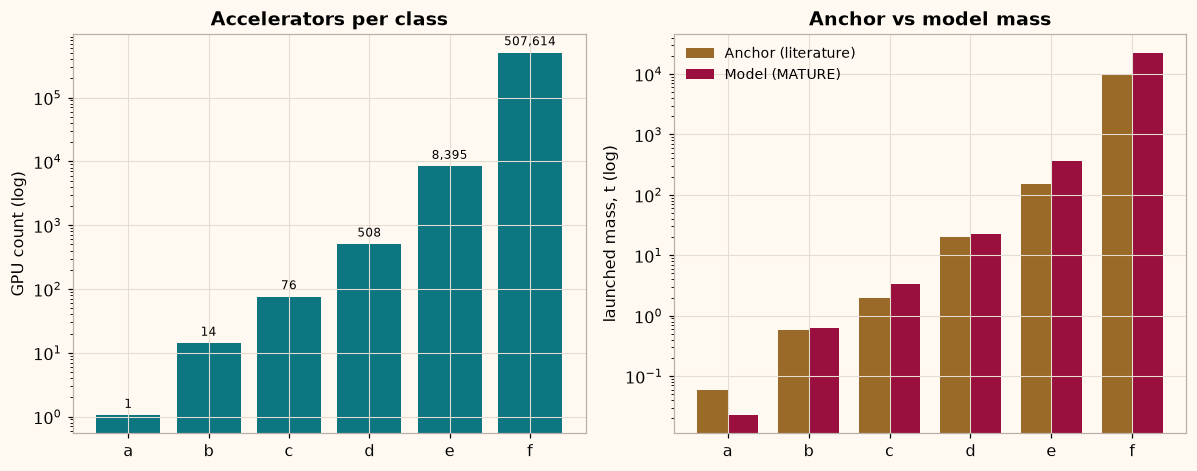

Rungs a-f: (a) ESPA edge node, (b) Single sat / small cluster, (c) Large sat (1 rack), (d) 1 MW node, (e) Assembled station, (f) GW constellation


In [17]:
fig, (a1,a2) = plt.subplots(1,2, figsize=(11,4.4))
keys = [r['key'] for r in lad]; counts = [r['gpu_count'] for r in lad]
a1.bar(keys, counts, color='#0D7680'); a1.set_yscale('log')
a1.set_ylabel('GPU count (log)'); a1.set_title('Accelerators per class')
for k,c in zip(keys,counts): a1.text(k, c*1.3, f"{c:,.0f}", ha='center', fontsize=8)
anc = [r['anchor_mass_t'] for r in lad]; mod = [r['model_dry_t'] for r in lad]
x = np.arange(len(keys)); w=0.38
a2.bar(x-w/2, anc, w, color='#9A6A28', label='Anchor (literature)')
a2.bar(x+w/2, mod, w, color='#990F3D', label='Model (MATURE)')
a2.set_yscale('log'); a2.set_xticks(x); a2.set_xticklabels(keys)
a2.set_ylabel('launched mass, t (log)'); a2.set_title('Anchor vs model mass'); a2.legend(frameon=False, fontsize=9)
plt.tight_layout(); plt.show()
print("Rungs a-f:", ", ".join(f"({r['key']}) {r['name']}" for r in lad))

## 13 · Orbit families
The orbit sets eclipse (→ battery + array), radiation dose (→ shielding + availability), comms latency (→ which workloads are viable), and drag (→ reboost). Dawn‑dusk SSO is the consensus default; the alternatives mostly illustrate *why* LEO wins. High‑LEO/MEO/GEO all fail the FCC 5‑yr deorbit rule without active disposal.

In [18]:
orows = []
for o in orbits.CATALOG.values():
    pt = power_thermal_mass(o.apply(TODAY))
    orows.append({'Orbit': o.name, 'Alt km': o.altitude_km, 'Daily eclipse %': round(o.eclipse_frac_daily*100,1),
                  'Sun %': round(o.sun_frac_annual*100), 'TID dose x': o.tid_dose_mult,
                  'RTT ms': o.latency_rtt_ms, 'FCC 5yr ok': o.fcc_deorbit_ok,
                  'Dry t/MW': round(pt['M_dry']/1e3,1)})
pd.DataFrame(orows).set_index('Orbit')

,Alt km,Daily eclipse %,Sun %,TID dose x,RTT ms,FCC 5yr ok,Dry t/MW
Orbit,,,,,,,
Dawn-dusk SSO (~550-650 km),600,2.4,98,1.0,5.0,True,56.8
Equatorial/inclined LEO (~550 km),550,36.0,64,1.1,5.0,True,65.9
"Higher LEO (~1,200-1,400 km)",1300,28.0,72,6.0,8.0,False,62.6
"MEO (~20,000 km)",20000,7.0,93,80.0,134.0,False,58.6
"GEO (~35,786 km)",35786,2.0,98,15.0,240.0,False,63.7


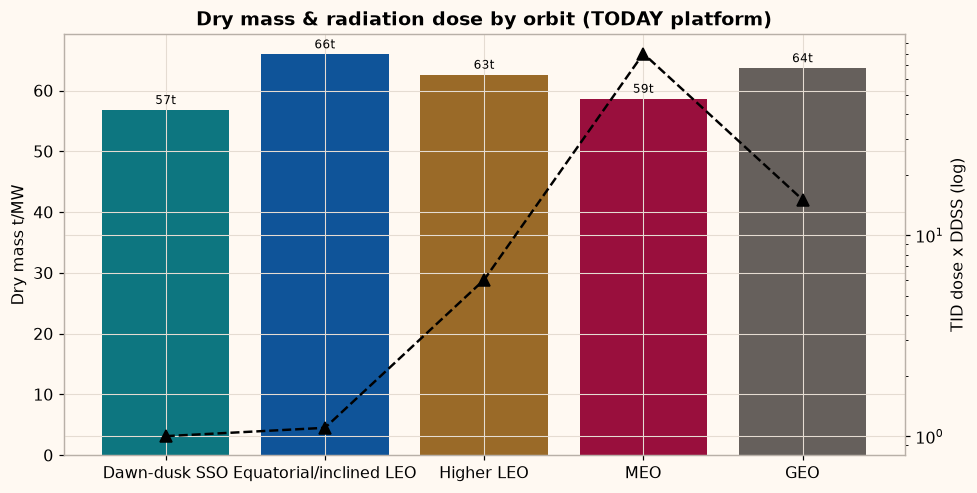

Equatorial LEO is heaviest (36% daily eclipse -> big array+battery); MEO/GEO add ~15-80x radiation dose
and 134-240 ms RTT that rules out latency workloads. DDSS is the consensus answer for good reason.


In [19]:
fig, ax = plt.subplots(figsize=(9,4.6))
onames = [o.name.split('(')[0].strip() for o in orbits.CATALOG.values()]
dry = [power_thermal_mass(o.apply(TODAY))['M_dry']/1e3 for o in orbits.CATALOG.values()]
dose = [o.tid_dose_mult for o in orbits.CATALOG.values()]
bars = ax.bar(onames, dry, color=['#0D7680','#0F5499','#9A6A28','#990F3D','#66605C'])
ax.set_ylabel('Dry mass t/MW'); ax.set_title('Dry mass & radiation dose by orbit (TODAY platform)')
ax2 = ax.twinx(); ax2.plot(onames, dose, 'k^--', lw=1.6, ms=8); ax2.set_yscale('log')
ax2.set_ylabel('TID dose x DDSS (log)')
for b,d in zip(bars,dry): ax.text(b.get_x()+b.get_width()/2, d+1, f"{d:.0f}t", ha='center', fontsize=8)
plt.tight_layout(); plt.show()
print("Equatorial LEO is heaviest (36% daily eclipse -> big array+battery); MEO/GEO add ~15-80x radiation dose")
print("and 134-240 ms RTT that rules out latency workloads. DDSS is the consensus answer for good reason.")

## 14 · Terrestrial‑first — the ground energy options space must beat
v2 collapsed the ground side to one \$/MWh. But energy is only ~\$0.6B of an ~\$8.5B/yr 1 GW ground TCO (Epoch AI) — the real ground pain is **time‑to‑power**: US interconnection queues run ~40 months to >7 years, and siting/water fights block \$64B of projects. So space competes on *speed and siting*, not cheaper electrons. The closest analog to orbital solar is ground solar+storage — and it's getting cheap, which *strengthens* the ground baseline.

In [20]:
grows = []
for s in ground_energy.CATALOG.values():
    grows.append({'Source': s.name, '$/MWh': s.usd_per_mwh, 'Time-to-power (mo)': s.time_to_power_months,
                  'Capacity factor': s.capacity_factor, 'kgCO2/MWh': s.carbon_kg_per_mwh,
                  'Dispatchable': s.dispatchable})
pd.DataFrame(grows).set_index('Source')

,$/MWh,Time-to-power (mo),Capacity factor,kgCO2/MWh,Dispatchable
Source,,,,,
"Grid (US industrial, DC-weighted)",83.0,48.0,0.95,370,False
Grid wholesale (ERCOT),30.0,48.0,0.90,350,False
Behind-the-meter gas turbine,75.0,8.0,0.92,450,True
SOFC fuel cell (Bloom),110.0,3.0,0.95,380,True
SMR (small modular reactor),120.0,54.0,0.92,12,True
Geothermal (Fervo-class EGS),88.0,30.0,0.90,20,True
Utility solar (standalone),58.0,12.0,0.25,30,False
Solar + storage,90.0,14.0,0.60,30,False
Off-grid solar+battery (Handmer),70.0,10.0,0.95,25,False


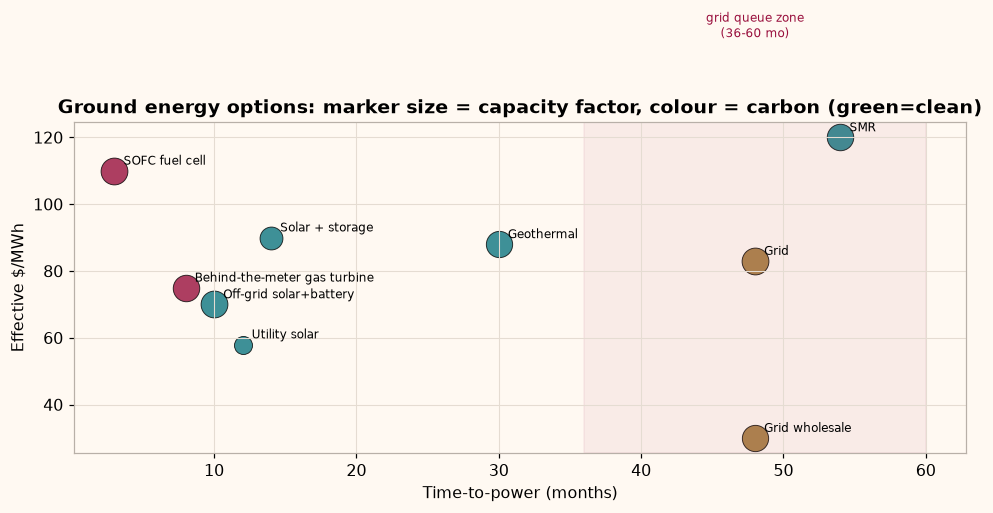

Space's pitch is the bottom-left of this chart: fast power without a queue. But gas turbines, fuel cells
and off-grid solar+battery already occupy that corner on Earth -- the queue argument is contestable.


In [21]:
fig, ax = plt.subplots(figsize=(9,5.0))
for s in ground_energy.CATALOG.values():
    col = '#0D7680' if s.carbon_kg_per_mwh < 50 else ('#9A6A28' if s.carbon_kg_per_mwh < 380 else '#990F3D')
    ax.scatter(s.time_to_power_months, s.usd_per_mwh, s=80+s.capacity_factor*240, color=col, alpha=.8, edgecolor='k', lw=.6)
    ax.annotate(s.name.split('(')[0].strip(), (s.time_to_power_months, s.usd_per_mwh),
                textcoords='offset points', xytext=(6,4), fontsize=8)
ax.axvspan(36, 60, color='#990F3D', alpha=.06)
ax.text(48, ax.get_ylim()[1]*0.96 if False else 150, 'grid queue zone\n(36-60 mo)', fontsize=8, color='#990F3D', ha='center')
ax.set_xlabel('Time-to-power (months)'); ax.set_ylabel('Effective $/MWh')
ax.set_title('Ground energy options: marker size = capacity factor, colour = carbon (green=clean)')
plt.tight_layout(); plt.show()
print("Space's pitch is the bottom-left of this chart: fast power without a queue. But gas turbines, fuel cells")
print("and off-grid solar+battery already occupy that corner on Earth -- the queue argument is contestable.")

## 15 · Provenance & verification ledger
Every load‑bearing default carries its source, a literature range, a confidence level, and the verdict from the 12‑claim adversarial review (`confirmed` / `partial` / `refuted`). This is what separates the model from a spreadsheet of guesses — and flags exactly where it is fragile (WACC, radiator W/m², array W/kg).

In [22]:
prov = []
for p in provenance.REGISTRY.values():
    prov.append({'Parameter': p.field, 'Central': p.central, 'Skeptic': p.low, 'Optimist': p.high,
                 'Unit': p.unit, 'Confidence': p.confidence, 'Verdict': p.verdict,
                 'Note': p.note[:70]})
pd.DataFrame(prov).set_index('Parameter')

,Central,Skeptic,Optimist,Unit,Confidence,Verdict,Note
Parameter,,,,,,,
launch_kg,1600.00,250.00,100.000,$/kg,high,partial,"$3,245/kg is naive list/expendable, not a quot..."
it_kg_per_kW,14.00,59.00,9.000,kg/kW,medium,confirmed,"System-level launched mass/kW, NOT IT-payload-..."
rad_areal_kg_m2,6.00,14.00,2.500,kg/m^2,medium,partial,Drop the '3.5 kg/m^2 MARVL' figure — MARVL is ...
radiator_W_m2,350.00,166.00,633.000,W/m^2,low,partial,T^4-driven; single biggest model sensitivity. ...
sp_array,110.00,75.00,400.000,W/kg,medium,refuted,REFUTES the 225 W/kg / 4.4 kg/kW claim — iROSA...
array_cost_W,30.00,35.00,4.000,$/W,low,partial,$90/m^2 InP cell-only confirmed; $4/W is a for...
life_yr,5.00,5.00,10.000,yr,high,partial,10-yr post-2032 collides with FCC deorbit lice...
g_facility_life_yr,15.00,15.00,15.000,yr,high,partial,Life mismatch drives the ~17-18x levelized rat...
wacc_space,0.15,0.20,0.103,frac,low,confirmed,MOST FRAGILE parameter. Non-repossessable/non-...


In [23]:
print("Academic citation anchors (Semantic Scholar, 12 Jun 2026):")
for k, v in sorted(provenance.CITATIONS.items(), key=lambda kv:-kv[1]):
    print(f"  {v:5d}  {k}")
print("\nVerification verdicts on the 12 load-bearing claims: 5 confirmed, 7 partial, 0 refuted-as-stated.")
print("Notable corrections folded into v3: iROSA is ~75 W/kg not 225 (REFUTED); radiator areal density")
print("~14 kg/m2 today not 3.5 (units conflation); launch $3,245/kg is naive list/expendable not a quote;")
print("Chinchilla has 3,361 cites not 2,596; the $/B-token throughput anchor (5,100 tok/s) is unverifiable.")

Academic citation anchors (Semantic Scholar, 12 Jun 2026):
   3361  Hoffmann et al., Chinchilla (2022)
   3311  Kaplan et al., Scaling Laws (2020)
   1613  Patterson et al., Carbon Footprint (2021)
    420  Luccioni et al., Inference Energy (FAccT 2024)
    292  Denby & Lucia, Orbital Edge Computing (ASPLOS 2020)
    224  Jones, Launch Cost (ICES 2018)
    129  Bhattacherjee et al., In-orbit Computing (HotNets 2020)
    104  Denby & Lucia, Machine Inference in Space (IEEE CAL 2019)
     67  Denby et al., Kodan (ASPLOS 2023)
     20  Google Project Suncatcher (arXiv:2511.19468, 2025)

Verification verdicts on the 12 load-bearing claims: 5 confirmed, 7 partial, 0 refuted-as-stated.
Notable corrections folded into v3: iROSA is ~75 W/kg not 225 (REFUTED); radiator areal density
~14 kg/m2 today not 3.5 (units conflation); launch $3,245/kg is naive list/expendable not a quote;
Chinchilla has 3,361 cites not 2,596; the $/B-token throughput anchor (5,100 tok/s) is unverifiable.


## 16 · Feasibility audit — demonstrated today vs needed

| Subsystem | Flown / demonstrated (mid‑2026) | Needed @ 1 MW node | Needed @ GW scale | Gap |
|---|---|---|---|---|
| **Compute in orbit** | H100 on Starcloud‑1 (Nov '25, LLM trained on orbit); Chinese "Three‑Body" constellation (>95% inference); TPU proton‑tested to 15 krad | ~500–1,000 accelerators, rad‑tolerant ops | ~10⁶ accelerators | **~10³–10⁶×** scale; reliability without repair |
| **Solar power** | ISS ≈ 240 kW; iROSA ~75 W/kg flight‑real (NOT 225); ROSA‑class spec ~110 W/kg | 1.3–1.5 MW BOL, ≥180 W/kg | GW‑class, ≥300 W/kg (unproven Mega‑ROSA), ~\$4/W | **~6× ISS** per node; W/kg target unproven |
| **Heat rejection** | ISS EATCS ≈ 70 kW from ~475 m²; ~150–200 W/m² proven floor | ~1.1 MW at 45–60 °C; W/m² is the headline sensitivity | ~GW, km² of radiator | **the least‑demonstrated subsystem** — 633 W/m² is not flight‑proven |
| **Optical links** | 100 Gbps ISL operational (Starlink); 1.6 Tbps single‑pair demo (Google) | multi‑Tbps mesh + 4+ ground stations | Pbps aggregate; bisection BW unquantified | Engineering scale‑up + weather diversity |
| **Radiation** | TPU to 15 krad TID; H100 operating on orbit; HBM weak from ~2 krad | ECC + checkpointing + ~1 t/MW shielding | same at fleet scale | Modest — Google data encouraging |
| **Launch** | F9 ~\$1.4–1.8k/kg; Starship in test | ≤\$500/kg sustained | ~\$250/kg target, ~180+ flights/yr | Gating but *not sufficient*: 2026 breakeven launch is negative |
| **Financing / insurance** | All‑equity (Starcloud); market caps ~\$300M/risk, ~\$0.5–0.7B/yr pool | self‑insure via redundancy | uninsurable at GW scale | **Structural** — no debt market for non‑repossessable assets |
| **Servicing / refresh** | None at scale (MEV is GEO‑only) | none (5‑yr write‑off) | robotic IT‑module swap | Unsolved; silicon obsolescence is structural |
| **Debris / regulatory** | FCC 5‑yr deorbit rule | standard (DDSS compliant) | km‑scale brightness, reentry alumina, spectrum | Material at GW scale |

## 17 · Conclusions

1. **Today (2026): not viable for general compute — and not because of launch.** Even at actual Falcon pricing the ratio is ~4.3–5.6×, and the breakeven launch price is **negative**: a 5‑yr / 15%‑WACC platform cannot beat a 15‑yr / 10.3% building at any rocket price. What *is* viable: in‑space edge processing, sovereignty niches, demonstrators.
2. **It is a conjunction bet.** Parity needs launch ≤ \$250/kg **and** mass < 15 kg/kW **and** radiators near ~600 W/m² **and** low‑Γ workloads **and** a financing regime that doesn't exist. The optimist↔skeptic band is ~14× wide (§3b) — *which literature you believe decides the answer*, and no single parameter closes it (Turyshev).
3. **The binding constraints, in order:** thermal (physical — radiators are the least‑demonstrated, most‑contested subsystem), the 5‑yr‑life × elevated‑WACC capital charge (economic), and workload commoditization (demand — token prices fall 10–50×/yr, so an orbital asset must earn back capex before its workload's unit value collapses).
4. **The demand side restricts the product.** Only low‑Γ training and batch inference close in orbit, and even training tops out around tens of MW per logical cluster before the downlink/bisection ceiling bites (§11). Latency chat — the highest \$/kWh — is structurally a ground product.
5. **The strongest near‑term case is time‑to‑power, not unit cost** (§10, §14) — but gas turbines, fuel cells and off‑grid solar+battery already occupy Earth's "fast power without a queue" corner, so the queue argument is contestable.
6. **Counterintuitive:** cheaper AI silicon *hurts* the space case — it shrinks shared IT capex while the orbital premium stays fixed (§7 tornado inversion). ODC viability prefers expensive, power‑hungry chips and scarce grid power.
7. **Parity, if it arrives, is 2035–2040**, tracking a terrestrially‑constrained world (SemiAnalysis's "Musk case") rather than their base case. Watch: Starcloud‑2 thermal performance, Suncatcher TPU+FSO results, Starship list pricing, and any flight demo of a >100 kW deployable radiator.

### Appendix · Interactive sliders (optional)
Run locally with `pip install ipywidgets` for live what‑ifs.

In [24]:
try:
    from ipywidgets import interact, FloatLogSlider, FloatSlider
    def what_if(launch=FloatLogSlider(value=700, base=10, min=1.7, max=3.78, description='$ /kg'),
                array_W=FloatSlider(value=12, min=2, max=40, step=1, description='array $/W'),
                spW=FloatSlider(value=180, min=60, max=450, step=10, description='W/kg'),
                Trad=FloatSlider(value=325, min=290, max=350, step=5, description='T_rad K'),
                elec=FloatSlider(value=95, min=40, max=250, step=5, description='grid $/MWh')):
        sc = replace(EARLY, launch_kg=launch, array_cost_W=array_W, sp_array=spW, T_rad=Trad, g_elec_MWh=elec)
        r = lcoc_and_npv(sc)
        print(f"dry {r['pt']['M_dry']/1e3:.1f} t/MW | capex ${r['cap_s']['total']:.0f}M vs ${r['cap_g']['total']:.0f}M | "
              f"LCOC {r['lcoc_s']:.2f} vs {r['lcoc_g']:.2f} $/kWh -> ratio {r['ratio']:.2f}x | "
              f"breakeven launch ${r['breakeven_launch']:,.0f}/kg")
    interact(what_if)
except ImportError:
    print("ipywidgets not installed -- pip install ipywidgets to enable the interactive panel.")

interactive(children=(FloatLogSlider(value=700.0, description='$ /kg', max=3.78, min=1.7), FloatSlider(value=1…